In [20]:
# 1.（30%）使用pandas库的相关方法，进行数据集读取、信息处理和探索性分析。
# Q1.（4%）读取数据集data.csv（将首列作为索引）至变量df，展示该数据集的前10行内容，并展示数据集有多少行和多少列。

import pandas as pd

df = pd.read_csv("data.csv")    # 读取csv文件，存储为dataframe类型
print(df.head(10))  # 输出前10行内容
print(f"数据集行数: {df.shape[0]}, 列数: {df.shape[1]}")    # 输出行数与列数

   Unnamed: 0  CNTRYID  CNT  CNTSCHID   CYC  NatCen  Region  STRATUM  \
0           1        8  ALB    800002  07MS     800     800  ALB0109   
1           2        8  ALB    800003  07MS     800     800  ALB0109   
2           3        8  ALB    800004  07MS     800     800  ALB0211   
3           4        8  ALB    800005  07MS     800     800  ALB0107   
4           5        8  ALB    800006  07MS     800     800  ALB0105   
5           6        8  ALB    800007  07MS     800     800  ALB0109   
6           7        8  ALB    800008  07MS     800     800  ALB0210   
7           8        8  ALB    800009  07MS     800     800  ALB0203   
8           9        8  ALB    800010  07MS     800     800  ALB0210   
9          10        8  ALB    800011  07MS     800     800  ALB0206   

   SUBNATIO  OECD  ...  EDUSHORT  STAFFSHORT  STUBEHA  TEACHBEHA  SCMCEG  \
0     80000     0  ...    1.2478     -1.4551  -1.1797    -2.0409 -1.0391   
1     80000     0  ...    0.6221     -1.4551   2.1196  

In [21]:
# Q2.（4%）数据集存在很多缺失值，输出各列缺失值的个数，并删除数据集的最后一列。基于更新后的数据，展示哪一列的缺失值最多，哪些列没有缺失值。

col_names = df.columns   # 取所有列名，方便展示
for col in col_names:
    num_isnull = df[col].isna().sum()   # 统计缺失值个数
    print(f"列名: {col}, 缺失值数: {num_isnull}")
    
df.drop(col, axis=1, inplace=True)  # 删除最后一列

col_names = df.columns   # 更新列名
max = 0 # 记录缺失值最大值
col_no_null = []   # 记录无缺失值列名
col_max_null = []    # 记录缺失值最多的列名（可能存在多个）

for col in col_names:
    num_isnull = df[col].isna().sum()
    if num_isnull == 0:
        col_no_null.append(col)    # 无缺失值
    if num_isnull > max:
        max = num_isnull    # 更新最多缺失值

for col in col_names:
    num_isnull = df[col].isna().sum()
    if max == num_isnull:
        col_max_null.append(col)    # 缺失值最多的列

print(f"缺失值最多的列为: ")
for col in col_max_null:
    print(f"\t{col}")
print(f"无缺失值的列为: ")
for col in col_no_null:
    print(f"\t{col}")

列名: Unnamed: 0, 缺失值数: 0
列名: CNTRYID, 缺失值数: 0
列名: CNT, 缺失值数: 0
列名: CNTSCHID, 缺失值数: 0
列名: CYC, 缺失值数: 0
列名: NatCen, 缺失值数: 0
列名: Region, 缺失值数: 0
列名: STRATUM, 缺失值数: 0
列名: SUBNATIO, 缺失值数: 0
列名: OECD, 缺失值数: 0
列名: ADMINMODE, 缺失值数: 0
列名: LANGTEST, 缺失值数: 786
列名: SC001Q01TA, 缺失值数: 1363
列名: SC013Q01TA, 缺失值数: 2092
列名: SC016Q01TA, 缺失值数: 3050
列名: SC016Q02TA, 缺失值数: 5603
列名: SC016Q03TA, 缺失值数: 6162
列名: SC016Q04TA, 缺失值数: 6793
列名: SC017Q01NA, 缺失值数: 1093
列名: SC017Q02NA, 缺失值数: 1149
列名: SC017Q03NA, 缺失值数: 1155
列名: SC017Q04NA, 缺失值数: 1244
列名: SC017Q05NA, 缺失值数: 1074
列名: SC017Q06NA, 缺失值数: 1111
列名: SC017Q07NA, 缺失值数: 1059
列名: SC017Q08NA, 缺失值数: 1072
列名: SC161Q01SA, 缺失值数: 1499
列名: SC161Q02SA, 缺失值数: 1499
列名: SC161Q03SA, 缺失值数: 1499
列名: SC161Q04SA, 缺失值数: 1499
列名: SC161Q05SA, 缺失值数: 1499
列名: SC162Q01SA, 缺失值数: 3657
列名: SC155Q01HA, 缺失值数: 1030
列名: SC155Q02HA, 缺失值数: 1041
列名: SC155Q03HA, 缺失值数: 1074
列名: SC155Q04HA, 缺失值数: 1041
列名: SC155Q05HA, 缺失值数: 1042
列名: SC155Q06HA, 缺失值数: 1027
列名: SC155Q07HA, 缺失值数: 1029
列名: SC155Q08HA, 缺失值数: 

In [22]:
# Q3.（4%）数据集的有些列在所有记录上均有相同取值，作为独立的一列是相对冗余的。请查找并输出这些列的名称和取值，并阐述这些列代表的含义，最后删除这些列。

col_dup = {}   # 记录冗余列名和取值
for col in col_names:
    if df[col].nunique() == 1:
        col_dup[col] = df[col].loc[0]   # 列中只有一种数值
    
print("冗余列：")
for col, value in col_dup.items():
    print(f"\t列名: {col}, 取值: {value}")

# CYC: PISA Assessment Cycle (2 digits + 2 character Assessment type - MS/FT)
# ADMINMODE: Mode of Respondent
#   1	Paper
#   2	Computer
#   SYSTEM MISSING	Missing


df.drop(columns=list(col_dup.keys()),inplace=True)

冗余列：
	列名: CYC, 取值: 07MS
	列名: ADMINMODE, 取值: 2


In [23]:
# Q4.（4%）观察PRIVATESCH特征列，统计所有取值及其出现的次数。其中有一部分取值含义一致但形式不同（如private和PRIVATE），试对它们进行归并，随后展示所有取值及其出现的次数。

value_count = df["PRIVATESCH"].value_counts() # 统计所有取值及其出现的次数
print("取值及出现次数: ")
for value, count in value_count.items():
    print(f"\t取值: {value}, 次数: {count}")

df["PRIVATESCH"] = df["PRIVATESCH"].replace(to_replace="PUBLIC", value="public")
df["PRIVATESCH"] = df["PRIVATESCH"].replace(to_replace="PRIVATE", value="private") # 归并

value_count = df["PRIVATESCH"].value_counts() # 统计所有取值及其出现的次数
print("取值及出现次数: ")
for value, count in value_count.items():
    print(f"\t取值: {value}, 次数: {count}")


取值及出现次数: 
	取值: public, 次数: 12161
	取值: missing, 次数: 5295
	取值: private, 次数: 3443
	取值: invalid, 次数: 251
	取值: PRIVATE, 次数: 84
	取值: PUBLIC, 次数: 73
取值及出现次数: 
	取值: public, 次数: 12234
	取值: missing, 次数: 5295
	取值: private, 次数: 3527
	取值: invalid, 次数: 251


In [24]:
# Q5.（5%）选取特征STUBEHA,TEACHBEHA,EDUSHORT,STAFFSHORT，展示它们的基本统计特征信息（平均值、标准差、四分位点、最小值、最大值、 Pearson相关系数矩阵）。

features = ["STUBEHA","TEACHBEHA","EDUSHORT","STAFFSHORT"]  # 需统计的特征

for col in features:
    print(f"列{col}的基本统计特征信息:")
    print(f"\t平均值: {df[col].mean()}")
    print(f"\t标准差: {df[col].std()}")
    print(f"\t25%分位数: {df[col].quantile(0.25)}")
    print(f"\t50%分位数: {df[col].quantile(0.5)}")
    print(f"\t75%分位数: {df[col].quantile(0.75)}")
    print(f"\t最大值: {df[col].max()}")
    print(f"\t最小值: {df[col].min()}")

pearson_matrix = df[features].corr(method="pearson")
print("Pearson相关系数矩阵：")
print(pearson_matrix)

列STUBEHA的基本统计特征信息:
	平均值: 0.041613881033408434
	标准差: 1.2365311162988104
	25%分位数: -0.6823
	50%分位数: 0.0417
	75%分位数: 0.8153
	最大值: 3.6274
	最小值: -4.3542
列TEACHBEHA的基本统计特征信息:
	平均值: 0.10823287441235728
	标准差: 1.1581542742625597
	25%分位数: -0.6218
	50%分位数: 0.2266
	75%分位数: 0.852425
	最大值: 3.8338
	最小值: -3.2392
列EDUSHORT的基本统计特征信息:
	平均值: 0.1207159936391673
	标准差: 1.091434381478892
	25%分位数: -0.6884
	50%分位数: 0.1
	75%分位数: 0.8339
	最大值: 3.5229
	最小值: -1.9319
列STAFFSHORT的基本统计特征信息:
	平均值: -0.013901473633517942
	标准差: 1.059586752743767
	25%分位数: -0.7828
	50%分位数: 0.0131
	75%分位数: 0.6736
	最大值: 4.1125
	最小值: -2.5891
Pearson相关系数矩阵：
             STUBEHA  TEACHBEHA  EDUSHORT  STAFFSHORT
STUBEHA     1.000000   0.633862  0.239674    0.257259
TEACHBEHA   0.633862   1.000000  0.215399    0.331982
EDUSHORT    0.239674   0.215399  1.000000    0.483617
STAFFSHORT  0.257259   0.331982  0.483617    1.000000


In [25]:
# Q7.（5%）执行以下子表提取操作：
# df1 = df[['PRIVATESCH', 'EDUSHORT', 'STAFFSHORT']]
# 并基于df1，以特征PRIVATESCH为先验条件，对其余各特征中可能存在的缺失值进行均值填补。

df1 = df[['PRIVATESCH', 'EDUSHORT', 'STAFFSHORT']] # 子表提取

# 展示填补前缺失值个数
print("填补前: ")
for col in df1.columns:
    num_isnull = df1[col].isna().sum()   # 统计缺失值个数
    print(f"列名: {col}, 缺失值数: {num_isnull}")

# 按PRIVATESCH属性分组（包括空值），计算均值
edu_mean = df1.groupby("PRIVATESCH",dropna=False)['EDUSHORT'].mean()
staff_mean = df1.groupby("PRIVATESCH",dropna=False)['STAFFSHORT'].mean()

# 将均值填补至缺失处
for i in range(df1.shape[0]):
    privatesch = df1.loc[i,"PRIVATESCH"]
    if pd.isna(df1.loc[i,"EDUSHORT"]):    
        df1.loc[i,"EDUSHORT"] = edu_mean[privatesch]
    if pd.isna(df1.loc[i,"STAFFSHORT"]):
        df1.loc[i,"STAFFSHORT"] = staff_mean[privatesch]

# 展示填补后缺失值个数
print("填补后: ")
for col in df1.columns:
    num_isnull = df1[col].isna().sum()   # 统计缺失值个数
    print(f"列名: {col}, 缺失值数: {num_isnull}")

填补前: 
列名: PRIVATESCH, 缺失值数: 596
列名: EDUSHORT, 缺失值数: 1151
列名: STAFFSHORT, 缺失值数: 1138
填补后: 
列名: PRIVATESCH, 缺失值数: 596
列名: EDUSHORT, 缺失值数: 0
列名: STAFFSHORT, 缺失值数: 0


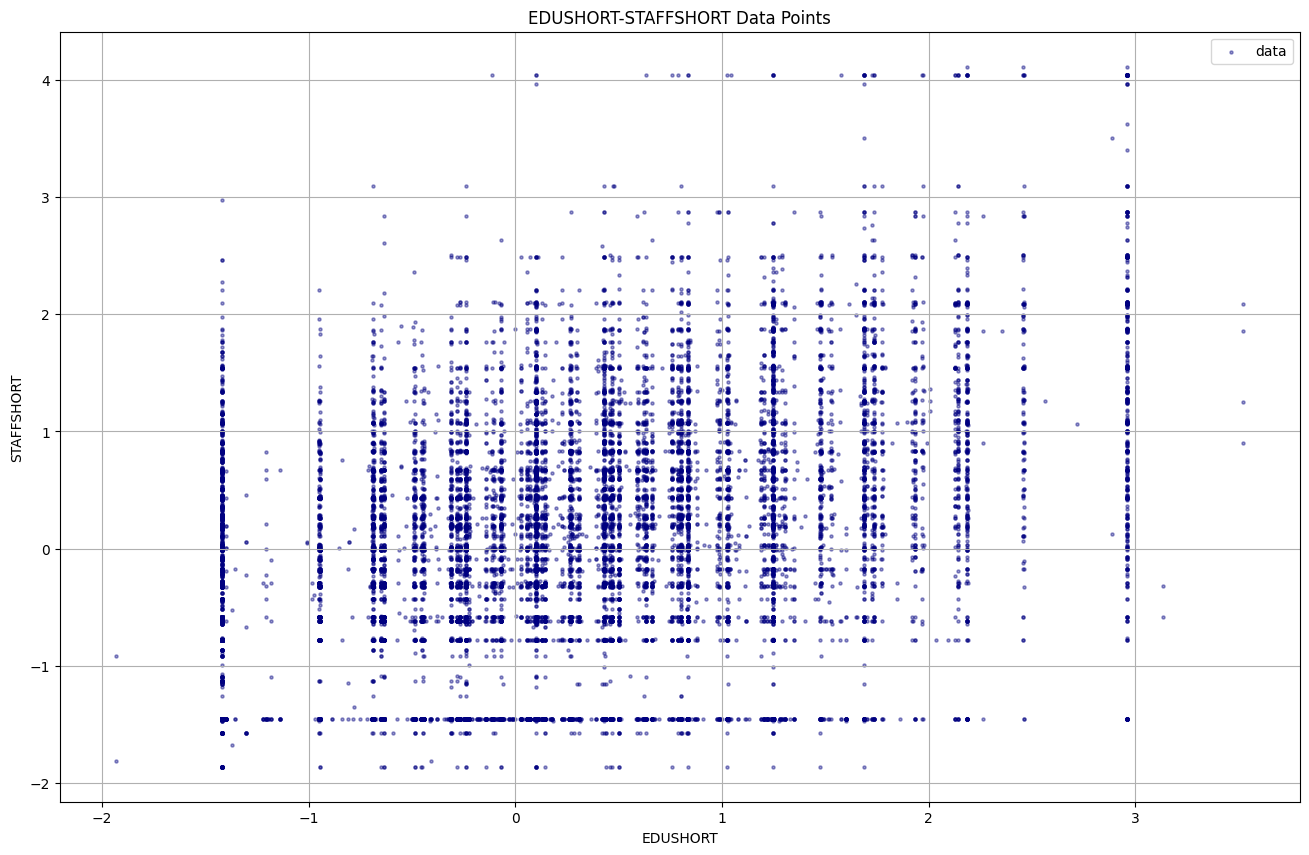

In [26]:
# 2.（17%）导入numpy和matplotlib库，对数据集df进行一定数据可视化分析。
# Q1.（5%）选择两个连续数值型特征，绘制其分布散点图，要求合理设置散点颜色和大小，并配上合适的标题和图例注记。

import numpy as np
import matplotlib.pyplot as plt

# 展示EDUSHORT和STAFFSHORT的分布散点图
plt.figure(figsize=(16, 10))
plt.scatter(df["EDUSHORT"], df["STAFFSHORT"], color="navy", label="data", s=5, alpha=0.4)
plt.xlabel("EDUSHORT")
plt.ylabel("STAFFSHORT")
plt.title("EDUSHORT-STAFFSHORT Data Points")
plt.legend()
plt.grid(True)
plt.show()

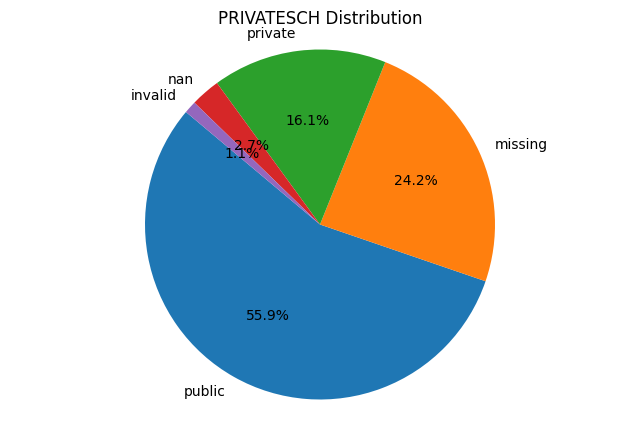

In [27]:
# Q2.（5%）选择一个离散数值型特征（建议所有取值数量不超过10），绘制饼图，要求设置合理配色和比例，并配上合适的标题和图例注记。

# 展示PRIVATESCH的分布饼图
value_count = df["PRIVATESCH"].value_counts(dropna=False)
plt.figure(figsize=(8,5))
plt.pie(value_count.values, labels=value_count.keys(), autopct='%1.1f%%', startangle=140)
plt.title("PRIVATESCH Distribution")
plt.axis("equal")
plt.show()

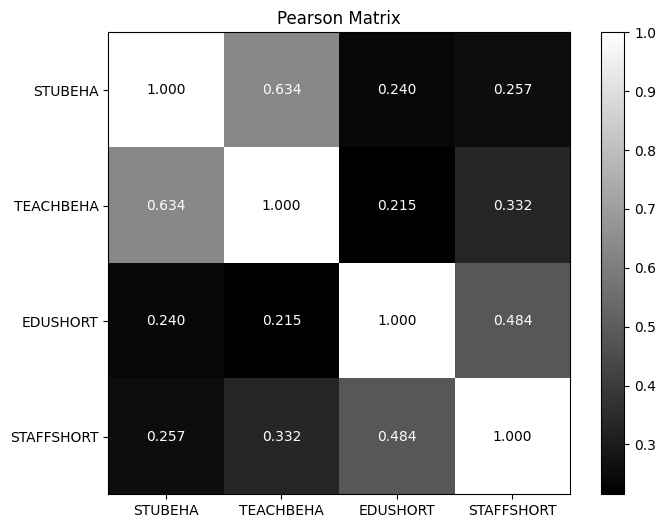

In [28]:
# Q3.（7%）对T1-Q5中的Pearson相关系数矩阵，绘制热力矩阵图，要求为每个位置增添对应数值表示（保留三位小数），设置数值与颜色的对应关系条，并配上合适的标题和坐标表示。

plt.figure(figsize=(8,6))
plt.imshow(pearson_matrix, cmap="gray", interpolation="nearest")    # 绘制热力图

# 标记数值
for i in range(pearson_matrix.shape[0]):
    for j in range(pearson_matrix.shape[1]):
        if pearson_matrix.iloc[i,j] > 0.7:
            plt.text(j, i, f'{pearson_matrix.iloc[i,j]:.3f}', ha='center', va='center', color='black')
        else:
            plt.text(j, i, f'{pearson_matrix.iloc[i,j]:.3f}', ha='center', va='center', color='white')

plt.title("Pearson Matrix")
# 标记坐标标签
plt.xticks([0, 1, 2, 3],pearson_matrix.keys())
plt.yticks([0, 1, 2, 3],pearson_matrix.keys())
# 绘制数值与颜色的对应关系条
plt.colorbar()
plt.show()


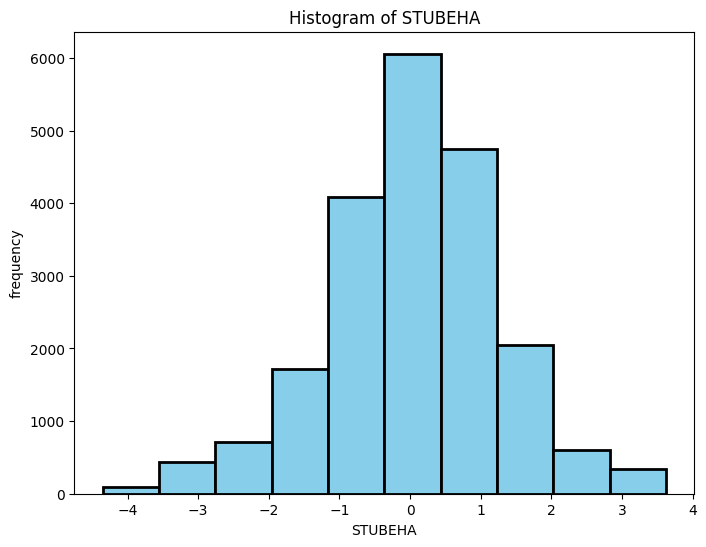

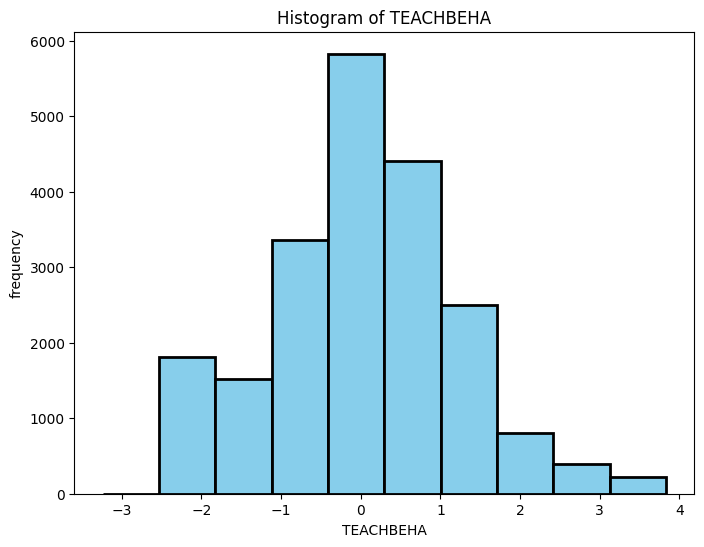

In [29]:
# 3.（23%）现欲对数据集特征STUBEHA,TEACHBEHA进行分布校验。执行以下子表提取和缺失记录删除操作：
# df2 = df[['STUBEHA', 'TEACHBEHA']].dropna()
# 并基于df2完成以下任务：
# Q1.（6%）以区间数为10，分别绘制两个特征的频数直方图，基于频数直方图的结果，是否可以认为两特征近似服从正态分布？

df2 = df[['STUBEHA', 'TEACHBEHA']].dropna()

# 绘制STUBEHA的直方图
plt.figure(figsize=(8,6))
plt.hist(df2["STUBEHA"], bins=10, color="skyblue", edgecolor="black", linewidth=2)
plt.xlabel("STUBEHA")
plt.ylabel("frequency")
plt.title("Histogram of STUBEHA")
plt.show()

# 绘制TEACHBEHA的直方图
plt.figure(figsize=(8,6))
plt.hist(df2["TEACHBEHA"], bins=10, color="skyblue", edgecolor="black", linewidth=2)
plt.xlabel("TEACHBEHA")
plt.ylabel("frequency")
plt.title("Histogram of TEACHBEHA")
plt.show()

<Figure size 800x600 with 0 Axes>

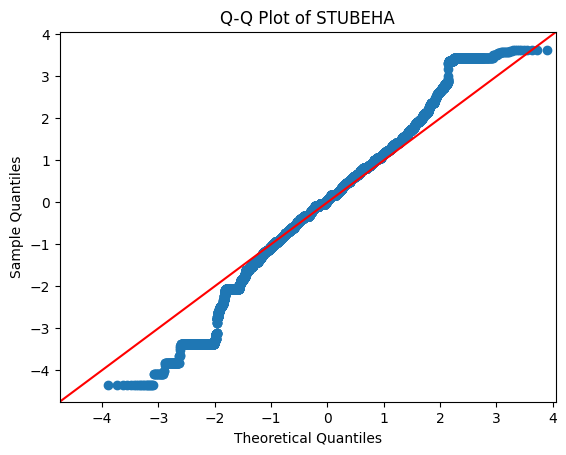

<Figure size 800x600 with 0 Axes>

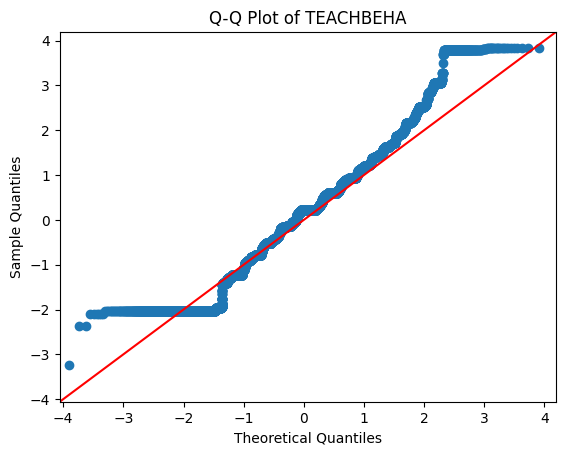

In [30]:
# Q2.（8%） Q-Q图（Quantile-Quantial Plot）又称为分位图，可简单直观地判断一组数据是否服从某种理论分布。例
# 如，若一容量为n的样本X服从标准正态分布，则其各分位点应与标准正态分布对应分位点完全一致。若从标准正态
# 分布抽样得到容量为n的样本Y，则散点(x_i,y_i)将近似分布于直线y=x上。单个特征样本Q-Q图可通过以下代码绘制：
# import statsmodels.api as sm
# import matplotlib.pyplot as plt
# sm.qqplot(data, line='45')
# plt.show()
# 参考上述代码，分别绘制这两个特征样本的Q-Q图，基于Q-Q图的结果，是否可以认为两特征近似服从正态分布？将
# 该结论与Q1所得结论进行对比，你有什么感想？

import statsmodels.api as sm

plt.figure(figsize=(8,6))
sm.qqplot(df2["STUBEHA"], line="45")
plt.title("Q-Q Plot of STUBEHA")
plt.show()

plt.figure(figsize=(8,6))
sm.qqplot(df2["TEACHBEHA"], line="45")
plt.title("Q-Q Plot of TEACHBEHA")
plt.show()

Q-Q图中两图像最大、最小值侧偏离较明显，中间部分大体位于y=x上，可以认为两特征近似服从正态分布，但的确存在一定偏离。
Q1中基于频数直方图的趋势猜测数据服从正态分布，结论不一定准确，并且当分组步长不够短时常常观察不到正态分布的特征；在Q-Q图中则可以较明显地表现出分布与正态分布的相似度，相对频数直方图较为准确。

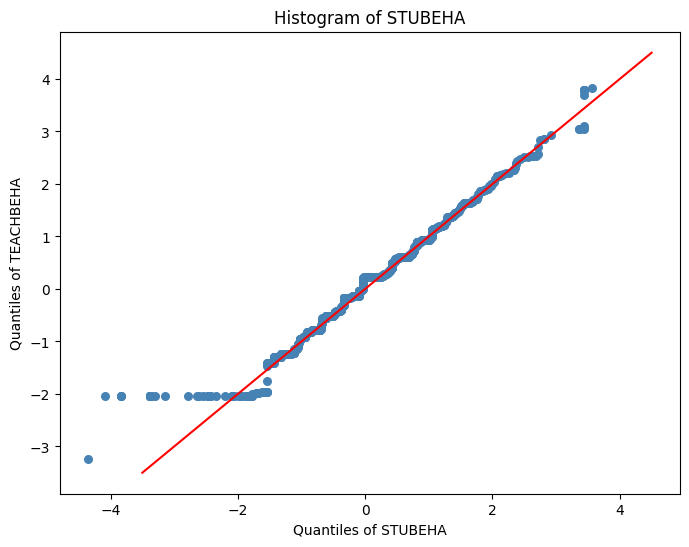

In [31]:
# Q3.（9%）特征STUBEHA与TEACHBEHA的理论分布是否具有一致性？请自行编写代码绘制两特征样本的Q-Q图和直线
# ，并基于可视化结果简述你的发现

# 取0到100百分位数，步长为0.1%
quan_stu = [df2["STUBEHA"].quantile(i) for i in np.arange(0, 1, 0.001)]
quan_tea = [df2["TEACHBEHA"].quantile(i) for i in np.arange(0, 1, 0.001)]

# 可视化
plt.figure(figsize=(8,6))
plt.scatter(quan_stu, quan_tea, color="steelblue", s=30)
plt.plot([-3.5,4.5], [-3.5,4.5], color="red")
plt.xlabel("Quantiles of STUBEHA")
plt.ylabel("Quantiles of TEACHBEHA")
plt.title("Histogram of STUBEHA")
plt.show()

In [32]:
# 4.（13%）基于正态分布假设，对特征STUBEHA,TEACHBEHA的总体分布进行参数估计。
# Q1.（8%）假设特征STUBEHA和TEACHBEHA样本分别独立同分布于正态分布$ N(\mu_1,\sigma_1^2) ,N(\mu_2,\sigma_2^2) $，请分别求均值参
# 数$\mu_1,\mu_2$和方差参数$ \sigma_1, \sigma_2 $的极大似然估计。作为总体均值和总体方差的估计，样本均值和样本方差均具有无偏性，请问上述极大似然估计是否也同样具有无偏性？
# 计算最大似然估计

stu_mu = df2["STUBEHA"].mean()
squared_diffs = (df2["STUBEHA"] - stu_mu) ** 2
stu_sigma2 = squared_diffs.mean()
print(f"STUBEHA的最大似然估计: mu = {stu_mu:.4f}, sigma^2 = {stu_sigma2:.4f}")

teach_mu = df2["TEACHBEHA"].mean()
squared_diffs = (df2["TEACHBEHA"] - stu_mu) ** 2
teach_sigma2 = squared_diffs.mean()
print(f"TEACHBEHA的最大似然估计: mu = {teach_mu:.4f}, sigma^2 = {teach_sigma2:.4f}")

STUBEHA的最大似然估计: mu = 0.0411, sigma^2 = 1.5289
TEACHBEHA的最大似然估计: mu = 0.1082, sigma^2 = 1.3458


In [33]:
#  设特征`STUBEHA`的样本为$ Y = (y_1,y_2,\dots,y_n) $，
# 对该特征进行常数估计$ y = a $，求参数$ a $的最小二乘解
# 并比较其与Q1中所得总体均值极大似然估计的结果。
# 计算a的最小二乘解

stu_a = df2["STUBEHA"].mean()
print(f"STUBEHA常数估计a的最小二乘解: a = {stu_a:.4f}")

STUBEHA常数估计a的最小二乘解: a = 0.0411


In [34]:
# Q2.（4%）使用scipy.stats中的相关方法，执行相应的假设检验。

from scipy.stats import ttest_rel

tvalue, pvalue = ttest_rel(df2["STUBEHA"],df2["TEACHBEHA"])

if tvalue >= 0:
    # 为拒绝原假设(t >= 0)，单侧检验p值应取t值左侧部分概率
    oneside_pvalue = 1 - pvalue/2
else:
    oneside_pvalue = pvalue/2

print(f"t值为: {tvalue}")
print(f"双侧检验p值为: {pvalue}")
print(f"单侧检验p值为: {oneside_pvalue}")

t值为: -9.420646242610308
双侧检验p值为: 4.936494108774419e-21
单侧检验p值为: 2.4682470543872093e-21
